# PassiveAggressiveClassifier - TF-IDF

Pipeline: Text cleaning -> TF-IDF unigram + bigram -> PassiveAggressiveClassifier.


## 1. Import thư viện

In [1]:
import os
import re
import json
import time
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Config

In [3]:
PROJECT_DIR = "/content/drive/MyDrive/Sentimental Analysis"

TRAIN_PATH = f"{PROJECT_DIR}/data_cleanedData/train.csv"
VAL_PATH = f"{PROJECT_DIR}/data_cleanedData/val.csv"
TEST_PATH = f"{PROJECT_DIR}/data_cleanedData/test.csv"

TEXT_COL = "text"
LABEL_COL = "status"

MODEL_DIR = f"{PROJECT_DIR}/model_results/PassiveAggressive"
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42
CMAP = "YlGnBu"

## 4. Text cleaning

In [4]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"&\w+;", " ", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

## 5. Load data

In [5]:
def load_dataset(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Không tìm thấy file: {path}")

    df = pd.read_csv(path)

    if TEXT_COL not in df.columns or LABEL_COL not in df.columns:
        raise ValueError(
            f"File {path} cần có 2 cột '{TEXT_COL}' và '{LABEL_COL}'. "
            f"Các cột hiện có: {list(df.columns)}"
        )

    df = df[[TEXT_COL, LABEL_COL]].dropna()
    df[TEXT_COL] = df[TEXT_COL].astype(str).apply(clean_text)
    df = df[df[TEXT_COL].str.len() > 0].reset_index(drop=True)

    return df


train_df = load_dataset(TRAIN_PATH)
val_df = load_dataset(VAL_PATH)
test_df = load_dataset(TEST_PATH)

print(f"Train size: {len(train_df):,}")
print(f"Val size:   {len(val_df):,}")
print(f"Test size:  {len(test_df):,}")

print("\nTrain label distribution:")
print(train_df[LABEL_COL].value_counts())

Train size: 34,596
Val size:   4,942
Test size:  9,886

Train label distribution:
status
normal        12702
depression    10154
suicidal       7839
anxiety        3901
Name: count, dtype: int64


## 6. Build pipeline

In [6]:
pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            max_features=100000,
            sublinear_tf=True,
            strip_accents="unicode"
        )
    ),
    (
        "clf",
        PassiveAggressiveClassifier(
            C=0.5,
            max_iter=1000,
            tol=1e-3,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

## 7. Train + đo training time

In [7]:
X_train = train_df[TEXT_COL]
y_train = train_df[LABEL_COL]

X_val = val_df[TEXT_COL]
y_val = val_df[LABEL_COL]

X_test = test_df[TEXT_COL]
y_test = test_df[LABEL_COL]

print("Training TF-IDF + PassiveAggressiveClassifier...")

start_train = time.perf_counter()
pipeline.fit(X_train, y_train)
train_time = time.perf_counter() - start_train

print("Training done.")
print(f"Training time: {train_time:.4f} seconds")

Training TF-IDF + PassiveAggressiveClassifier...
Training done.
Training time: 13.6514 seconds


## 8. Confusion matrix

In [8]:
def plot_confusion_matrix_png(cm, labels, split_name):
    title = f"{split_name.upper()} Confusion Matrix"
    file_name = f"{split_name}_confusion_matrix.png"

    fig, ax = plt.subplots(figsize=(8, 6))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(
        ax=ax,
        cmap=CMAP,
        values_format="d",
        xticks_rotation=45,
        colorbar=True
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Predicted label", fontsize=12)
    ax.set_ylabel("True label", fontsize=12)

    plt.tight_layout()

    save_path = os.path.join(MODEL_DIR, file_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved confusion matrix plot: {save_path}")

## 9. Evaluate + đo inference time

===== VAL RESULT =====
Accuracy:             0.7612
Macro F1:             0.7449
Weighted F1:          0.7590
Inference time total: 0.9251 seconds
Avg inference time:   0.00018718 seconds/sample

              precision    recall  f1-score   support

     anxiety     0.8109    0.7469    0.7776       557
  depression     0.6741    0.6657    0.6699      1451
      normal     0.8828    0.9338    0.9076      1814
    suicidal     0.6370    0.6125    0.6245      1120

    accuracy                         0.7612      4942
   macro avg     0.7512    0.7397    0.7449      4942
weighted avg     0.7577    0.7612    0.7590      4942



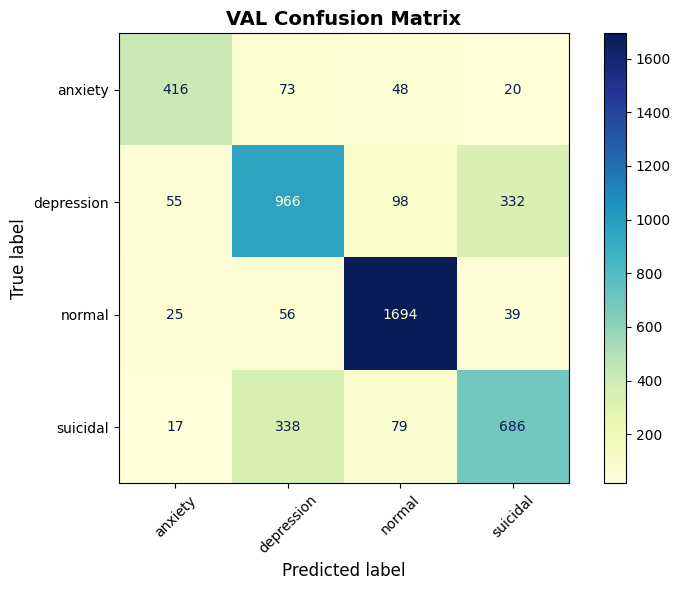

Saved confusion matrix plot: /content/drive/MyDrive/Sentimental Analysis/model_results/PassiveAggressive/val_confusion_matrix.png
===== TEST RESULT =====
Accuracy:             0.7661
Macro F1:             0.7522
Weighted F1:          0.7645
Inference time total: 1.5979 seconds
Avg inference time:   0.00016163 seconds/sample

              precision    recall  f1-score   support

     anxiety     0.8276    0.7534    0.7887      1115
  depression     0.6716    0.6892    0.6803      2902
      normal     0.8836    0.9245    0.9036      3629
    suicidal     0.6579    0.6156    0.6361      2240

    accuracy                         0.7661      9886
   macro avg     0.7602    0.7457    0.7522      9886
weighted avg     0.7639    0.7661    0.7645      9886



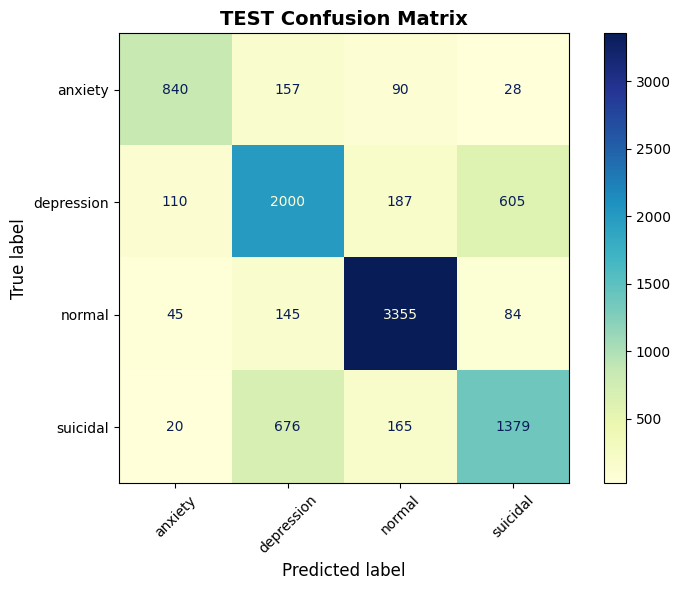

Saved confusion matrix plot: /content/drive/MyDrive/Sentimental Analysis/model_results/PassiveAggressive/test_confusion_matrix.png


In [9]:
def evaluate_model(split_name, X, y_true):
    start_infer = time.perf_counter()
    y_pred = pipeline.predict(X)
    infer_time_total = time.perf_counter() - start_infer
    infer_time_avg = infer_time_total / len(X)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"===== {split_name.upper()} RESULT =====")
    print(f"Accuracy:             {acc:.4f}")
    print(f"Macro F1:             {macro_f1:.4f}")
    print(f"Weighted F1:          {weighted_f1:.4f}")
    print(f"Inference time total: {infer_time_total:.4f} seconds")
    print(f"Avg inference time:   {infer_time_avg:.8f} seconds/sample")
    print()

    print(classification_report(y_true, y_pred, digits=4))

    labels = sorted(pd.Series(y_true).unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    pred_df = pd.DataFrame({
        "text": X.values,
        "true_label": y_true.values,
        "pred_label": y_pred
    })
    pred_df.to_csv(os.path.join(MODEL_DIR, f"{split_name}_predictions.csv"), index=False)

    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    cm_df.to_csv(os.path.join(MODEL_DIR, f"{split_name}_confusion_matrix.csv"))

    plot_confusion_matrix_png(cm, labels, split_name)

    report_dict = classification_report(y_true, y_pred, digits=4, output_dict=True)
    with open(os.path.join(MODEL_DIR, f"{split_name}_classification_report.json"), "w", encoding="utf-8") as f:
        json.dump(report_dict, f, indent=4, ensure_ascii=False)

    return {
        "split": split_name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "infer_time_total_sec": infer_time_total,
        "infer_time_avg_sec_per_sample": infer_time_avg
    }


val_metrics = evaluate_model("val", X_val, y_val)
test_metrics = evaluate_model("test", X_test, y_test)

## 10. Save model + metrics

In [10]:
model_path = os.path.join(MODEL_DIR, "passive_aggressive_tfidf.joblib")
joblib.dump(pipeline, model_path)

metrics = {
    "model": "TF-IDF + PassiveAggressiveClassifier",
    "feature_extraction": {
        "tfidf": {
            "analyzer": "word",
            "ngram_range": [1, 2],
            "min_df": 3,
            "max_df": 0.95,
            "max_features": 100000,
            "sublinear_tf": True
        }
    },
    "classifier": {
        "name": "PassiveAggressiveClassifier",
        "C": 0.5,
        "max_iter": 1000,
        "tol": 1e-3,
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    },
    "training_time_sec": train_time,
    "val": val_metrics,
    "test": test_metrics,
    "val_infer_time_total_sec": val_metrics["infer_time_total_sec"],
    "val_infer_time_avg_sec_per_sample": val_metrics["infer_time_avg_sec_per_sample"],
    "test_infer_time_total_sec": test_metrics["infer_time_total_sec"],
    "test_infer_time_avg_sec_per_sample": test_metrics["infer_time_avg_sec_per_sample"]
}

with open(os.path.join(MODEL_DIR, "metrics_summary.json"), "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4, ensure_ascii=False)

print(f"Saved model to: {model_path}")
print(f"Saved metrics to: {os.path.join(MODEL_DIR, 'metrics_summary.json')}")
print(f"Saved reports and confusion matrices to folder: {MODEL_DIR}")

Saved model to: /content/drive/MyDrive/Sentimental Analysis/model_results/PassiveAggressive/passive_aggressive_tfidf.joblib
Saved metrics to: /content/drive/MyDrive/Sentimental Analysis/model_results/PassiveAggressive/metrics_summary.json
Saved reports and confusion matrices to folder: /content/drive/MyDrive/Sentimental Analysis/model_results/PassiveAggressive


## 11. Demo prediction

In [11]:
def predict_text(text):
    cleaned = clean_text(text)
    return pipeline.predict([cleaned])[0]


sample_text = "I feel anxious and my heart is racing all the time"
print("Sample prediction:")
print(f"Text: {sample_text}")
print(f"Prediction: {predict_text(sample_text)}")

Sample prediction:
Text: I feel anxious and my heart is racing all the time
Prediction: anxiety
